In [488]:
import matplotlib.pyplot as plt
import numpy as np
import scipy
from scipy.integrate import quad, dblquad
from scipy.interpolate import interp1d

In [489]:
fontsize = 15

plt.rcParams.update({
    # taglia della figura
    'figure.figsize': (8,6),

    # font
    'text.usetex': True,
    'font.family': 'cmr10',
    'mathtext.fontset': 'cm',
    'axes.formatter.use_mathtext': True,
    'figure.titlesize' : fontsize,

    # assi
    'axes.labelsize': fontsize,
    'axes.titlesize': fontsize,
    'axes.linewidth': 1.5,
    'axes.axisbelow': True,

    # griglia
    'axes.grid': True,
    'grid.alpha': 0.2,

    # ticks
    'xtick.labelsize': fontsize,
    'ytick.labelsize': fontsize,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.minor.size': 3,
    'ytick.minor.size': 3,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.minor.width': 0.6,
    'ytick.minor.width': 0.6,    
    'xtick.major.pad': 8,

    # legenda
    'legend.fontsize': fontsize,

    # plots
    #'lines.linewidth': 1.6,
    #'scatter.marker': 'o',
    #'lines.markersize': 8,
    'scatter.edgecolors': 'black'
})

In [490]:
#plt.rcParams.update(plt.rcParamsDefault)

# Spettro angolare

In [491]:
# Parametri cosmologici
H0 = 68                                         # parametro di Hubble in km/(s*Mpc)
h = H0 / 100
T0 = 2.7                                        # Temperatura della radiazione in K
c = 299792.458                                  # Velocità della luce in km/s
G = 6.67430e-20                                 # Costante di gravitazione in km^3/(kg*s^2)
sigma_SB = 5.670374419e-8                       # Costante di Stefan-Boltzmann in kg/(s^3*K^4)
Neff = 3.046                                    # Numero efficace di specie di neutrini

Mpc_to_km = 3.085677581e19                      # km/Mpc
H0_s = H0 / Mpc_to_km                           # Conversione H0 in s^-1
rho_crit = (3 * H0_s**2) / (8 * np.pi * G)      # Densità critica in kg/km^3
a = 4*sigma_SB / c                              # Costante di radiazione in kg/(s^3*K^4)
rho_rad = a * T0**4 / c**2                      # Densità della radiazione in kg/m^3

Or = rho_rad / rho_crit                         # Parametro di densità della radiazione
Om = 0.3                                        # Parametro di densità della materia
Or = Or * (1 + 7/8 * (4/11)**(4/3) * Neff)      # Parametro di densità della radiazione
Ol = 1 - Om - Or                                # Parametro di densità della costante cosmologica

In [492]:
conversion = lambda l: (l*(l+1)) / (2*np.pi)

In [493]:
# carico i dati del matter power spectrum e dello spettro della CMB
k, Pk = np.loadtxt('test_lcdm_z1_pk.dat', unpack=True, usecols=(0,1))
k = k * h           # Converto da h/Mpc a 1/Mpc
Pk = Pk / h**3      # Converto P(k) da (Mpc/h)^3 a Mpc^3

CMB_data = np.loadtxt('test_lcdm_cl.dat')
CMB_l = CMB_data[:,0]
CMB_defl = CMB_data[:,1:] / conversion(CMB_l)[:, None]
CMB_TT, CMB_EE, CMB_TE, CMB_BB, CMB_ff, CMB_Tf, CMB_Ef = CMB_defl[:,0], CMB_defl[:,1], CMB_defl[:,2], CMB_defl[:,3], CMB_defl[:,4], CMB_defl[:,5], CMB_defl[:,6]

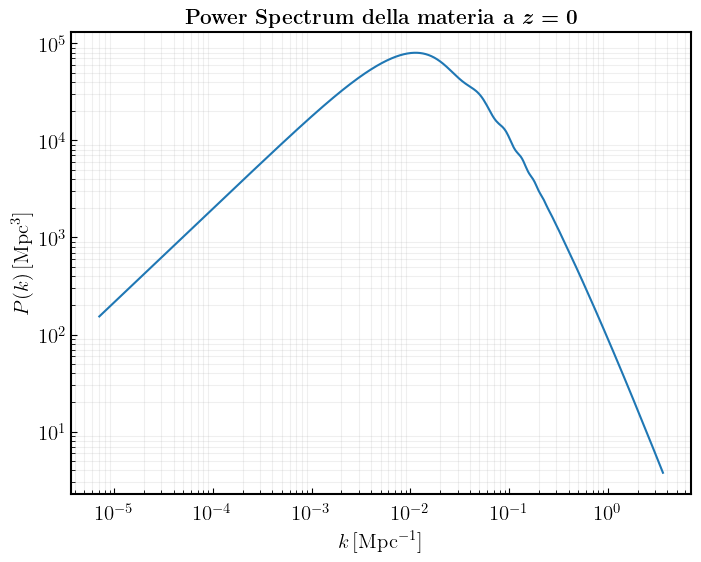

In [494]:
plt.loglog(k, Pk, label=r'$P(k)$')

plt.xlabel(r'$k \, [\mathrm{Mpc}^{-1}]$')
plt.ylabel(r'$P(k) \, [\mathrm{Mpc}^3]$')
plt.title(r'\textbf{Power Spectrum della materia a \boldmath{$z=0$}}')
plt.grid(which='both')

plt.show()

In [495]:
# definisco la funzione H(z) e la integro per ottenere chi a z=1.5

# parametro di Hubble in funzione di z
H = lambda z: H0 * np.sqrt(Om * (1+z)**3 + Or * (1+z)**4 + Ol)

chi = lambda z: quad(lambda x: c / H(x), 0, z)[0]

In [496]:
# interpolo i dati del P(k,0)
Pk_inter = interp1d(np.log(k), np.log(Pk), kind='linear', fill_value="extrapolate")

# per calcolare il P(k,z) ad un determinato z, definisco il growth factor usando l'eq 8.76
D_integr = lambda z: (1 + z) / H(z)**3
D0 = (H(0)/H0) * quad(D_integr, 0, np.inf)[0]
D = lambda z: (H(z)/H0) * quad(D_integr, z, np.inf)[0] / D0     

# calcolo il P(k,z) usando la formula P(k,z) = P(k,0) * D(z)^2, ricordando che P(k,0) è dato dai dati
P_k_z = lambda k, z: np.exp(Pk_inter(np.log(k))) * D(z)**2

In [497]:
# definisco i redshift di interesse
z_gal = 1.5
z_rec = 1089

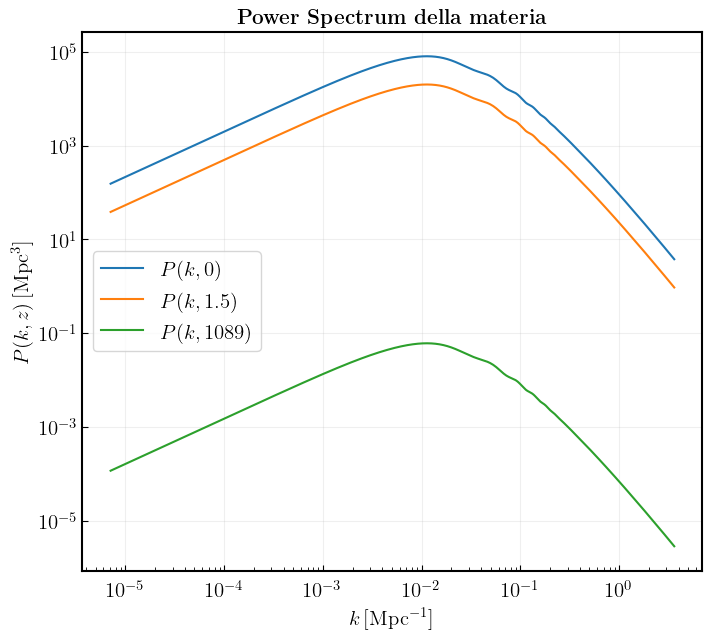

In [498]:
plt.figure(figsize=(8,7))
plt.loglog(k, P_k_z(k,0), label=r'$P(k, 0)$')
plt.loglog(k, P_k_z(k,z_gal), label=f'$P(k, {z_gal})$')
plt.loglog(k, P_k_z(k,z_rec), label=f'$P(k, {z_rec})$')

plt.xlabel(r'$k \, [\mathrm{Mpc}^{-1}]$')
plt.ylabel(r'$P(k,z) \, [\mathrm{Mpc}^3]$')
plt.title(r'\textbf{Power Spectrum della materia}')
#plt.grid(which='both')
plt.legend()

plt.show()

In [499]:
# definisco l'integranda per il C_kk

def Ckk_integ(z_s):
    
    cost = ((3/2) * Om *(H0/c)**2)**2

    def integranda(z, l):

        ch = chi(z)
        # definisco il kernel per il lensing
        gl = lambda z: 1 - ch/chi(z_s)

        k = l / ch
        jacob = c / H(z)

        return jacob * cost * ((1+z) * gl(z))**2 * P_k_z(k, z)
    
    return integranda

In [500]:
# calcolo l'integrale fino a z_gal e fino alla ricombinazione

l_val = 2*np.logspace(0, 3.2, 50)
C_kk_zsr = np.ones(len(l_val)) / (2 * np.pi)
C_kk_rec = np.ones(len(l_val)) / (2 * np.pi)

for i, l in enumerate(l_val):
    C_kk_zsr[i] *= quad(Ckk_integ(z_gal), 0, z_gal, args=(l,))[0] * (l*(l+1))
    C_kk_rec[i] *= quad(Ckk_integ(z_rec), 0, z_rec, args=(l,))[0] * (l*(l+1))


/var/folders/ll/brfzdrlx3nndb4spv5812khr0000gn/T/ipykernel_5229/1284304786.py:9: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  C_kk_rec[i] *= quad(Ckk_integ(z_rec), 0, z_rec, args=(l,))[0] * (l*(l+1))


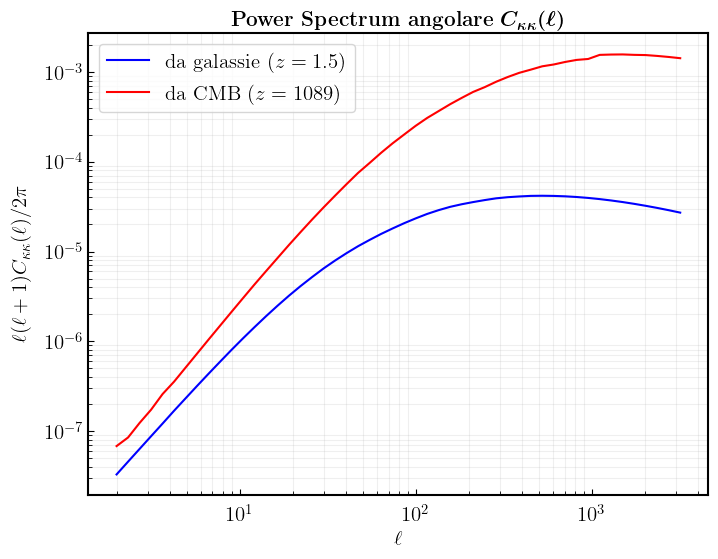

In [501]:
plt.loglog(l_val, C_kk_zsr, color='blue', label=f'da galassie $(z={z_gal})$')
plt.loglog(l_val, C_kk_rec, color='red', label=f'da CMB $(z={z_rec})$')

plt.xlabel(r'$\ell$')
plt.ylabel(r'$\ell(\ell+1)C_{\kappa\kappa}(\ell)/2\pi$', labelpad=10)
plt.title(r'\textbf{Power Spectrum angolare} \boldmath{$C_{\kappa \kappa}(\ell)$}')
plt.grid(which='both')
plt.legend()

plt.show()

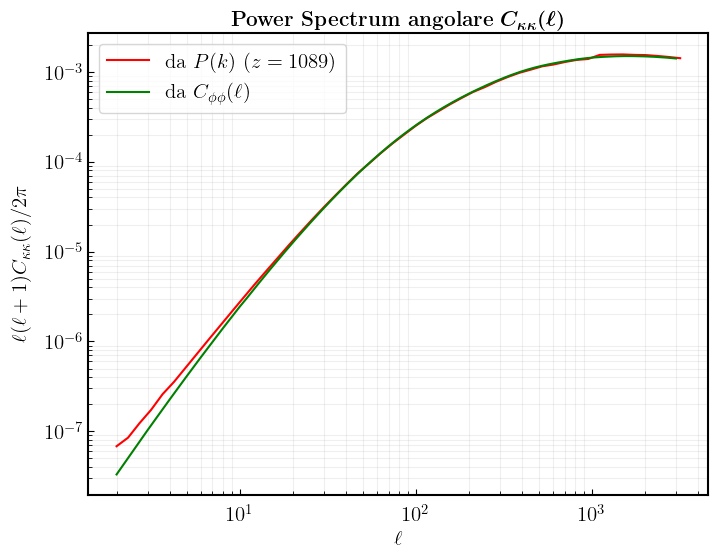

In [502]:
plt.loglog(l_val, C_kk_rec, color='red', label=f'da $P(k) \ (z={z_rec})$')
plt.loglog(CMB_l, (CMB_ff*conversion(CMB_l))*(CMB_l**4/4), color='green', label=r'da $C_{\phi \phi}(\ell)$')

plt.xlabel(r'$\ell$')
plt.ylabel(r'$\ell(\ell+1)C_{\kappa\kappa}(\ell)/2\pi$', labelpad=10)
plt.title(r'\textbf{Power Spectrum angolare} \boldmath{$C_{\kappa \kappa}(\ell)$}')
plt.grid(which='both')
plt.legend()

plt.show()

# Spettro della temperatura

In [503]:
# interpolo i dati del C_ff e C_TT
C_ff = interp1d(CMB_l, CMB_ff, kind='linear', fill_value="extrapolate")
C_ff_calc = interp1d(l_val, C_kk_rec / (conversion(l_val) * (l_val**4/4)), kind='linear', fill_value="extrapolate")
C_TT = interp1d(CMB_l, CMB_TT, kind='linear', fill_value="extrapolate")

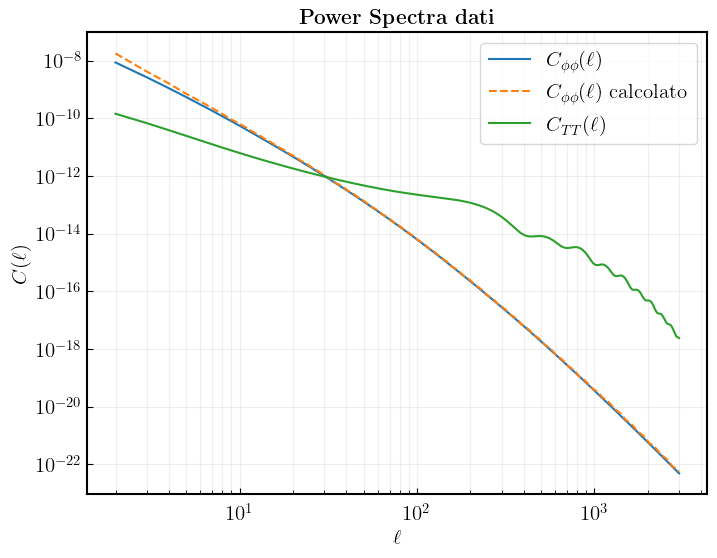

In [504]:
# grafico i dati
plt.loglog(CMB_l, C_ff(CMB_l), label=r'$C_{\phi \phi}(\ell)$')
plt.loglog(CMB_l, C_ff_calc(CMB_l), linestyle='--', label=r'$C_{\phi \phi}(\ell)$ calcolato')
plt.loglog(CMB_l, C_TT(CMB_l), label=r'$C_{TT}(\ell)$')

plt.xlabel(r'$\ell$')
plt.ylabel(r'$C(\ell)$')
plt.title(r'\textbf{Power Spectra dati}')
plt.grid(which='minor')
plt.legend()

plt.show()

In [505]:
# griglia di valori con reshape
l_min = np.min(CMB_l)
l_max = np.max(CMB_l)
n_l = 400

l_integr = np.logspace(np.log10(l_min), np.log10(l_max), n_l)
phi_values = np.linspace(0, 2*np.pi, 200)
l_2D, phi_2D = np.meshgrid(l_integr, phi_values)        # asse 0: angolo, asse 1: l
#l_values = np.logspace(np.log10(20), np.log10(2600), n_l)
l_values = np.linspace(20, 2700, n_l)

In [506]:
# calcolo le correzioni C_13 e C_22 per ogni l
def len_corr_temp(l):

    # 2*C_13
    C_13 = -1/(4*np.pi) * l**2 * C_TT(l) * quad(
        lambda l1: l1**3 * C_ff(l1),
        l_min, l_max
        )[0]
    
    # C_22
    l_l1_norm = np.sqrt(l**2 + l_2D**2 - 2*l*l_2D*np.cos(phi_2D))               # |l - l1|, shape: (300, 500)
    l_l1_fatt = l_2D*(l_2D * l * np.cos(phi_2D) - l_2D**2)**2                   # |l1|*[l1 • (l-l1)]^2, shape: (300, 500)
    C22_int = (1/(4*np.pi**2)) * l_l1_fatt * C_ff(l_2D) * C_TT(l_l1_norm)       # integranda, shape: (300, 500)

    res_phi = np.trapezoid(C22_int, phi_values, axis=0)
    res_l1 = np.trapezoid(res_phi, l_integr)
    C_22 = res_l1

    return C_13, C_22

# definisco array per i vari cotributi
C_TT_unl = np.zeros(len(l_values))
C_TT_len = np.zeros(len(l_values))
C_13 = np.zeros(len(l_values))
C_22 = np.zeros(len(l_values))

# calcolo lo spettro con lensing
for i, l in enumerate(l_values):
    C_TT_unl[i] = C_TT(l)
    C_13[i], C_22[i] = len_corr_temp(l)
    C_TT_len[i] = C_TT_unl[i] + C_22[i] + C_13[i]


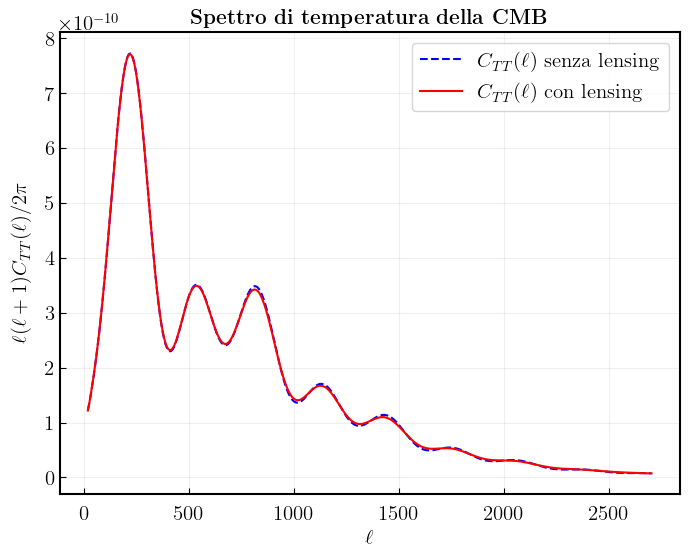

In [507]:
# grafico le differenze tra spettro lensed e unlensed
plt.plot(l_values, conversion(l_values)*C_TT_unl, color='blue', linestyle='--', label=r'$C_{TT}(\ell)$ senza lensing')
plt.plot(l_values, conversion(l_values)*C_TT_len, color='red', label=r'$C_{TT}(\ell)$ con lensing')

plt.title(r'\textbf{Spettro di temperatura della CMB}')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\ell(\ell+1)C_{TT}(\ell)/2\pi$', labelpad=10)
plt.legend()
plt.show()

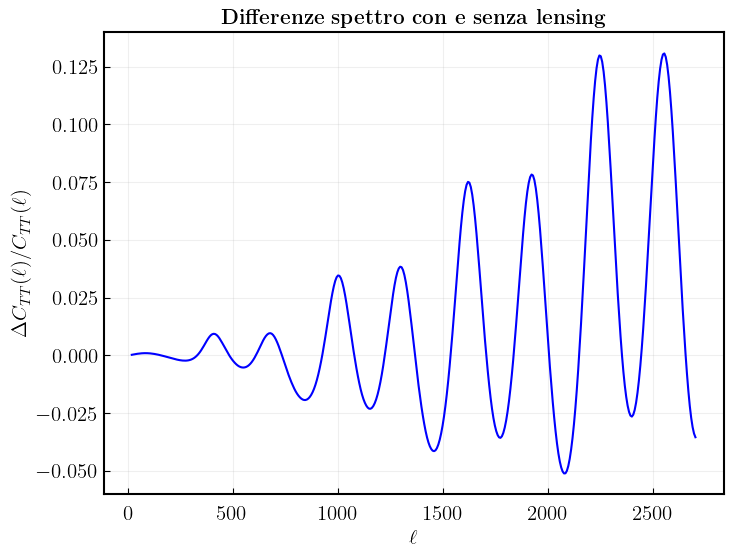

In [508]:
# grafico il la differenza tra spettro lensed e unlensed
diff = (C_TT_len - C_TT_unl)/C_TT_unl
plt.plot(l_values, diff, color='blue')

plt.title(r'\textbf{Differenze spettro con e senza lensing}')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\Delta C_{TT}(\ell)/C_{TT}(\ell)$')
plt.grid(which='minor')
plt.show()

Ricalcolo gli spettri con il $C_{\phi \phi}$ calcolato

In [509]:
# calcolo le correzioni C_13 e C_22 per ogni l
def len_corrections(l):

    # C_13
    C_13 = -1/(4*np.pi) * l**2 * C_TT(l) * quad(
        lambda l1: l1**3 * C_ff_calc(l1),
        l_min, l_max
        )[0]
    
    # C_22
    l_l1_norm = np.sqrt(l**2 + l_2D**2 - 2*l*l_2D*np.cos(phi_2D))       # |l - l1|, shape: (300, 500)
    l_l1_fatt = l_2D*(l_2D * l * np.cos(phi_2D) - l_2D**2)**2           # |l1|*[l1 • (l-l1)]^2, shape: (300, 500)
    C22_int = l_l1_fatt * C_ff_calc(l_2D) * C_TT(l_l1_norm)             # integranda, shape: (300, 500)

    res_phi = np.trapezoid(C22_int, phi_values, axis=0)
    res_l1 = np.trapezoid(res_phi, l_integr)
    C_22 = res_l1 / (4 * np.pi**2)

    return C_13, C_22

# definisco array per i vari cotributi
C_TT_unl = np.zeros(len(l_values))
C_TT_len = np.zeros(len(l_values))
C_13 = np.zeros(len(l_values))
C_22 = np.zeros(len(l_values))

# calcolo lo spettro con lensing
for i, l in enumerate(l_values):
    C_TT_unl[i] = C_TT(l)
    C_13[i], C_22[i] = len_corrections(l)
    C_TT_len[i] = C_TT_unl[i] + C_22[i] + C_13[i]


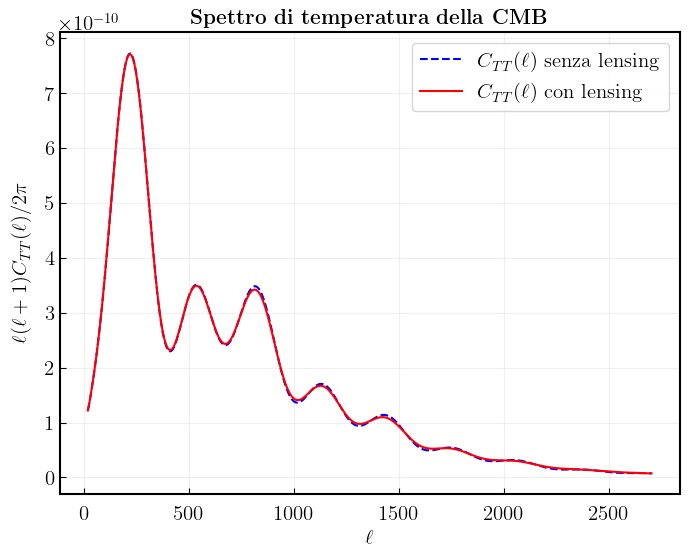

In [510]:
# grafico lo spettro lensed e unlensed
plt.plot(l_values, conversion(l_values)*C_TT_unl, color='blue', linestyle='--', label=r'$C_{TT}(\ell)$ senza lensing')
plt.plot(l_values, conversion(l_values)*C_TT_len, color='red', label=r'$C_{TT}(\ell)$ con lensing')

plt.title(r'\textbf{Spettro di temperatura della CMB}')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\ell(\ell+1)C_{TT}(\ell)/2\pi$', labelpad=10)
plt.legend()
plt.show()

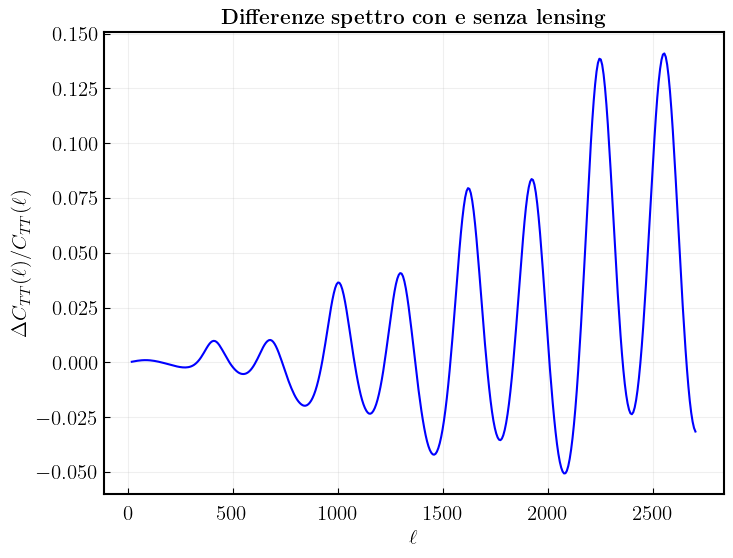

In [511]:
# grafico il la differenza tra spettro lensed e unlensed
diff = (C_TT_len - C_TT_unl)/C_TT_unl
plt.plot(l_values, diff, color='blue')

plt.title(r'\textbf{Differenze spettro con e senza lensing}')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\Delta C_{TT}(\ell)/C_{TT}(\ell)$')
plt.grid(which='minor')
plt.show()

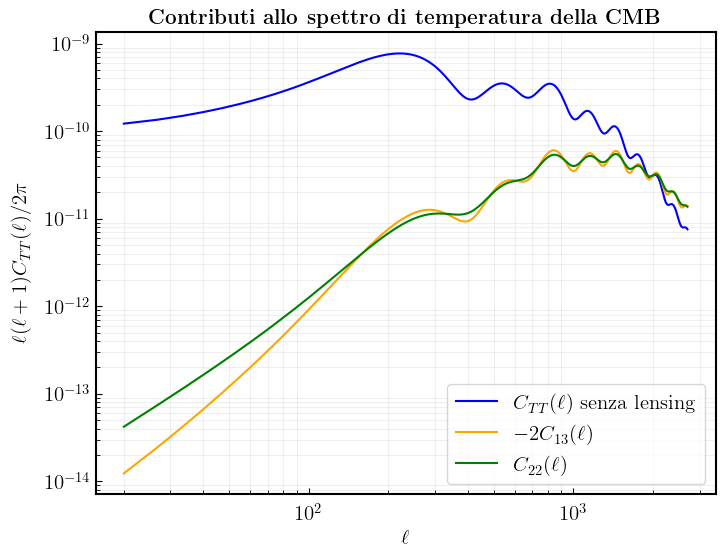

In [512]:
# garfico tutti i contributi allo spettro con lensing
plt.loglog(l_values, conversion(l_values) * C_TT_unl, color='blue', label=r'$C_{TT}(\ell)$ senza lensing')
plt.loglog(l_values, conversion(l_values) * (-C_13), color='orange', label=r'$-2C_{13}(\ell)$')
plt.loglog(l_values, conversion(l_values) * C_22, color='green', label=r'$C_{22}(\ell)$')

plt.xlabel(r'$\ell$')
plt.ylabel(r'$\ell(\ell+1)C_{TT}(\ell)/2\pi$', labelpad=10)
plt.title(r'\textbf{Contributi allo spettro di temperatura della CMB}')
plt.grid(which='both')
plt.legend()
plt.show()

# Spettro della polarizzazione

In [513]:
# interpolo i dati
C_EE = interp1d(CMB_l, CMB_EE, kind='linear', fill_value="extrapolate")
C_BB = interp1d(CMB_l, CMB_BB, kind='linear', fill_value="extrapolate")

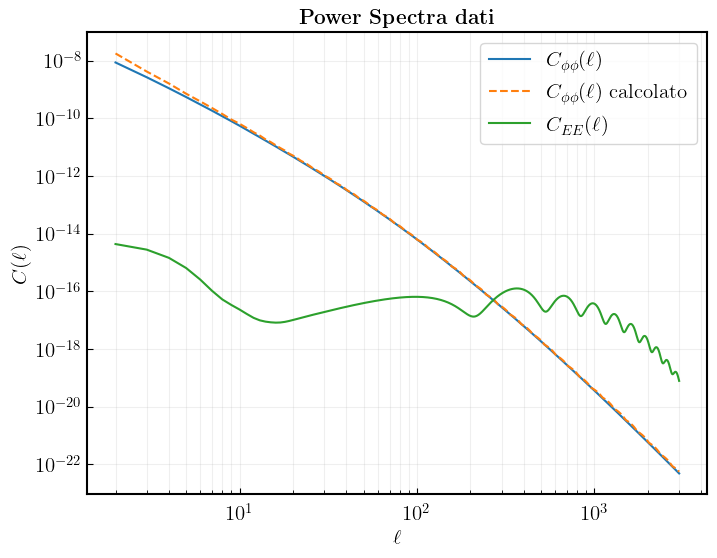

In [514]:
# grafico i dati
plt.loglog(CMB_l, C_ff(CMB_l), label=r'$C_{\phi \phi}(\ell)$')
plt.loglog(CMB_l, C_ff_calc(CMB_l), linestyle='--', label=r'$C_{\phi \phi}(\ell)$ calcolato')
plt.loglog(CMB_l, C_EE(CMB_l), label=r'$C_{EE}(\ell)$')

plt.xlabel(r'$\ell$')
plt.ylabel(r'$C(\ell)$')
plt.title(r'\textbf{Power Spectra dati}')
plt.grid(which='minor')
plt.legend()

plt.show()

In [515]:
# calcolo le correzioni C_13 e C_22 per ogni l
def len_corr_polariz(l):

    # 2*C_13
    C_13 = -1/(4*np.pi) * l**2 * C_EE(l) * quad(
        lambda l1: l1**3 * C_ff(l1),
        l_min, l_max
        )[0]
    
    # C_22_EE, C_22_BB
    l_l1_norm = np.sqrt(l**2 + l_2D**2 - 2*l*l_2D*np.cos(phi_2D))               # |l - l1|, shape: (300, 500)
    l_l1_fatt = l_2D*(l_2D * l * np.cos(phi_2D) - l_2D**2)**2                   # |l1|*[l1 • (l-l1)]^2, shape: (300, 500)
    phi_l_l1 = np.arctan((l_2D * np.sin(phi_2D)) / (l_2D*np.cos(phi_2D) - l))   # angolo di l-l1, shape: (300, 500)
    cos_fatt = (np.cos(2*phi_l_l1))**2                                            # fattore coseno E-modes, shape: (300, 500)
    sin_fatt = (np.sin(2*phi_l_l1))**2                                            # fattore seno B-modes, shape: (300, 500)
    C22_int = (1/(4*np.pi**2)) * l_l1_fatt * C_ff(l_2D) * C_EE(l_l1_norm)       # integranda, shape: (300, 500)

    res_phi_EE = np.trapezoid(C22_int * cos_fatt, phi_values, axis=0)
    C_22_EE = np.trapezoid(res_phi_EE, l_integr)

    res_phi_BB = np.trapezoid(C22_int * sin_fatt, phi_values, axis=0)
    C_22_BB = np.trapezoid(res_phi_BB, l_integr)

    return C_13, C_22_EE, C_22_BB

# definisco array per i vari cotributi
C_EE_unl = np.zeros(len(l_values))
C_EE_len = np.zeros(len(l_values))
C_BB_unl = np.zeros(len(l_values))
C_BB_len = np.zeros(len(l_values))
C_13_EE = np.zeros(len(l_values))
C_22_EE = np.zeros(len(l_values))
C_22_BB = np.zeros(len(l_values))

# calcolo lo spettro con lensing
for i, l in enumerate(l_values):
    C_EE_unl[i] = C_EE(l)
    C_BB_unl[i] = C_BB(l)
    C_13_EE[i], C_22_EE[i], C_22_BB[i] = len_corr_polariz(l)
    C_EE_len[i] = C_EE_unl[i] + C_22_EE[i] + C_13_EE[i]
    C_BB_len[i] = C_BB_unl[i] + C_22_BB[i]


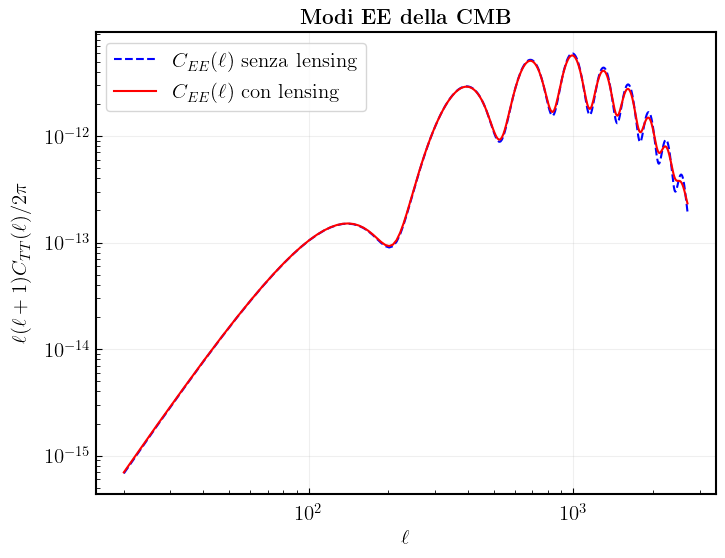

In [516]:
# grafico gli spettri EE lensed e unlensed
plt.loglog(l_values, conversion(l_values)*C_EE_unl, color='blue', linestyle='--', label=r'$C_{EE}(\ell)$ senza lensing')
plt.loglog(l_values, conversion(l_values)*C_EE_len, color='red', label=r'$C_{EE}(\ell)$ con lensing')

plt.title(r'\textbf{Modi EE della CMB}')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\ell(\ell+1)C_{TT}(\ell)/2\pi$', labelpad=10)
plt.legend()
plt.show()

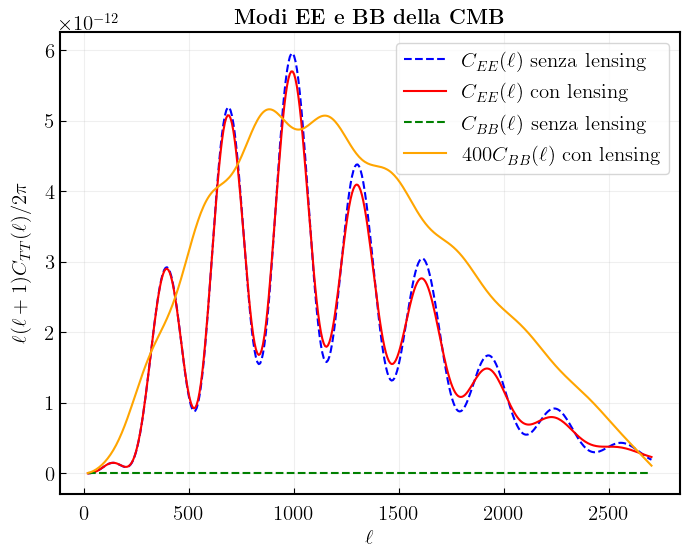

In [517]:
# grafico gli spettri lensed e unlensed
plt.plot(l_values, conversion(l_values)*C_EE_unl, color='blue', linestyle='--', label=r'$C_{EE}(\ell)$ senza lensing')
plt.plot(l_values, conversion(l_values)*C_EE_len, color='red', label=r'$C_{EE}(\ell)$ con lensing')
plt.plot(l_values, conversion(l_values)*C_BB_unl, color='green', linestyle='--', label=r'$C_{BB}(\ell)$ senza lensing')
plt.plot(l_values, conversion(l_values)*C_BB_len*400, color='orange', label=r'$400C_{BB}(\ell)$ con lensing')

plt.title(r'\textbf{Modi EE e BB della CMB}')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\ell(\ell+1)C_{TT}(\ell)/2\pi$', labelpad=10)
plt.legend()
plt.show()